Import Libraries

In [160]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Read The File


In [161]:
df = pd.read_excel("Telco_customer_churn.xlsx")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


Exploratory Data Analysis (EDA)


In [162]:
df.shape

(7043, 33)

In [163]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [164]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


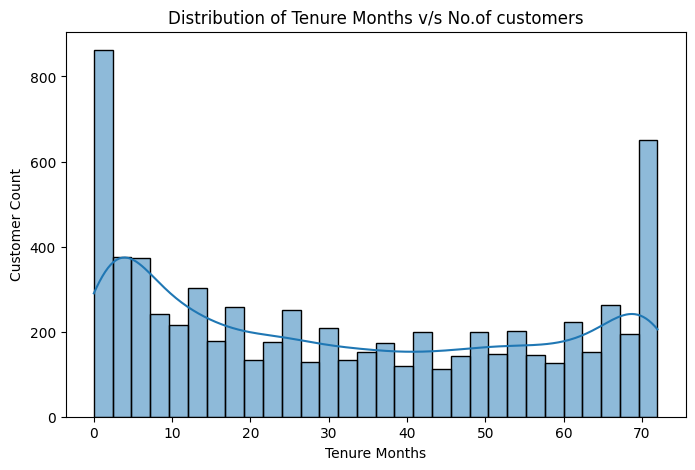

In [165]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure Months'], bins=30, kde=True)
plt.title('Distribution of Tenure Months v/s No.of customers')
plt.xlabel('Tenure Months')
plt.ylabel('Customer Count')
plt.show()

In [166]:
df['Tenure Months'].max()

72

In [167]:
df['Tenure Months'].min()

0

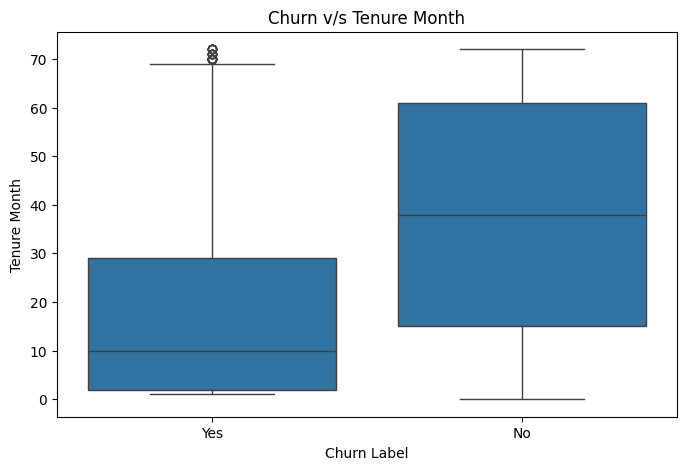

In [168]:
plt.figure(figsize=(8,5))
sns.boxplot(x = 'Churn Label', y = 'Tenure Months', data = df)
plt.title('Churn v/s Tenure Month')
plt.xlabel('Churn Label')
plt.ylabel('Tenure Month')
plt.show()

In [169]:
df['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

In [170]:
df[df['Churn Label'] == 'Yes']

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1864,1699-HPSBG,1,United States,California,Palm Springs,92264,"33.745746, -116.514215",33.745746,-116.514215,Male,...,One year,Yes,Electronic check,59.80,727.8,Yes,1,69,4581,Competitor offered higher download speeds
1865,8775-CEBBJ,1,United States,California,Seeley,92273,"32.790282, -115.689559",32.790282,-115.689559,Female,...,Month-to-month,Yes,Bank transfer (automatic),44.20,403.35,Yes,1,87,2029,Competitor offered higher download speeds
1866,6894-LFHLY,1,United States,California,Vidal,92280,"34.264124, -114.717964",34.264124,-114.717964,Male,...,Month-to-month,Yes,Electronic check,75.75,75.75,Yes,1,97,5571,Competitor offered higher download speeds
1867,0639-TSIQW,1,United States,California,White Water,92282,"33.972293, -116.654195",33.972293,-116.654195,Female,...,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes,1,70,5620,Competitor offered more data


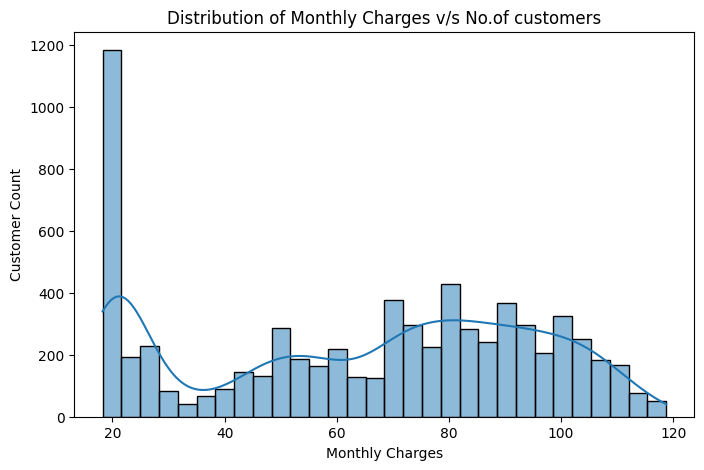

In [171]:
plt.figure(figsize=(8,5))
sns.histplot(df['Monthly Charges'], bins=30, kde=True)
plt.title('Distribution of Monthly Charges v/s No.of customers')
plt.xlabel('Monthly Charges')
plt.ylabel('Customer Count')
plt.show()

In [172]:
df['Monthly Charges'].max()

118.75

In [173]:
df['Monthly Charges'].min()

18.25

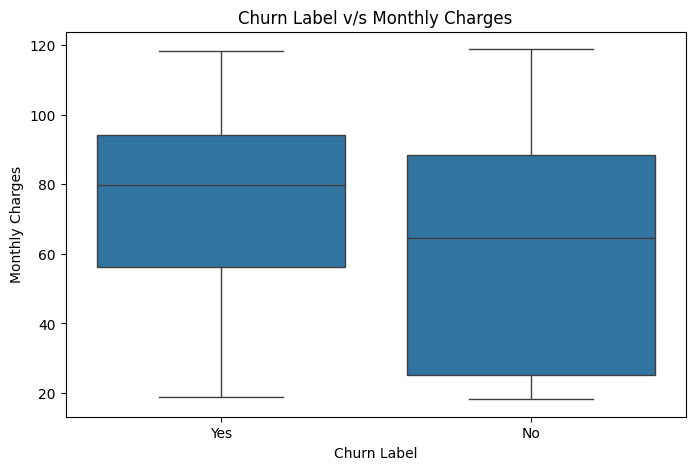

In [174]:
plt.figure(figsize=(8,5))
sns.boxplot(x = 'Churn Label', y = 'Monthly Charges', data = df)
plt.title('Churn Label v/s Monthly Charges')
plt.xlabel('Churn Label')
plt.ylabel('Monthly Charges')
plt.show()

In [175]:
df[df['Churn Label']=='Yes']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,56.15
0.50,79.65
0.75,94.20


In [176]:
df[df['Churn Label']=='No']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,25.100
0.50,64.425
0.75,88.400


In [177]:
df['Monthly Charges'].describe()

,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [178]:
df['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,35.50
0.50,70.35
0.75,89.85


In [179]:
df['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

In [180]:
df['Contract'].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


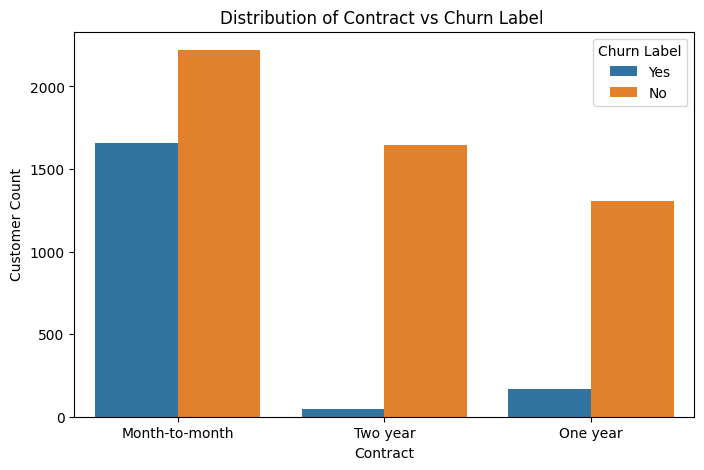

In [181]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn Label', data=df)
plt.xlabel('Contract')
plt.ylabel('Customer Count')
plt.title('Distribution of Contract vs Churn Label ')
plt.show()

In [182]:
df['Internet Service'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

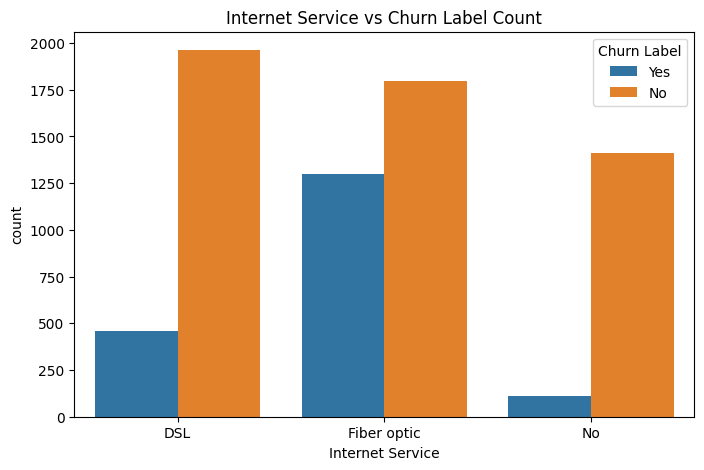

In [183]:
plt.figure(figsize=(8,5))
sns.countplot(x='Internet Service', hue='Churn Label', data=df)
plt.xlabel('Internet Service')
plt.ylabel('count')
plt.title('Internet Service vs Churn Label Count')
plt.show()

In [184]:
df['Payment Method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

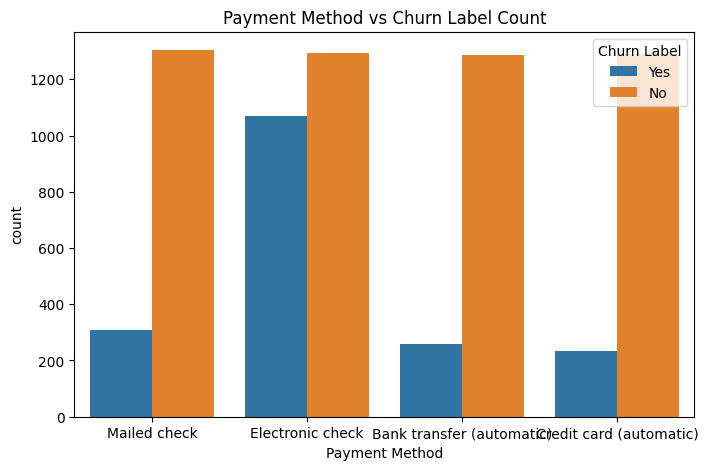

In [185]:
plt.figure(figsize=(8,5))
sns.countplot(x='Payment Method', hue='Churn Label', data=df)
plt.xlabel('Payment Method')
plt.ylabel('count')
plt.title('Payment Method vs Churn Label Count')
plt.show()

In [186]:
df['Tech Support'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

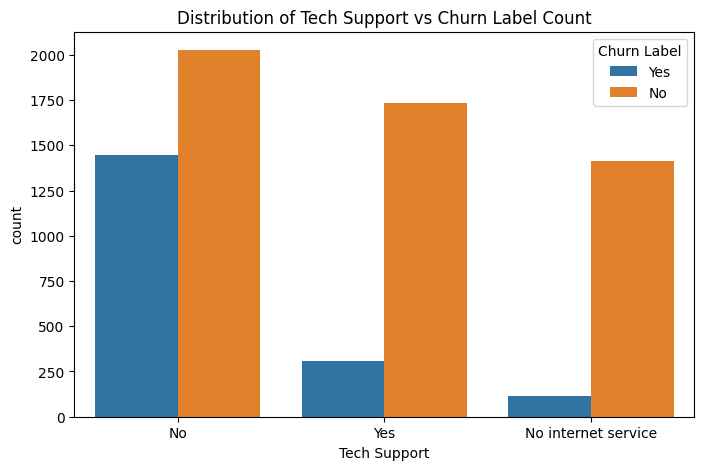

In [187]:
plt.figure(figsize=(8,5))
sns.countplot(x='Tech Support', hue='Churn Label', data=df)
plt.xlabel('Tech Support')
plt.ylabel('count')
plt.title('Distribution of Tech Support vs Churn Label Count')
plt.show()

In [188]:
avg_tenure = df.groupby("Churn Label")["Tenure Months"].mean()
avg_tenure

,Tenure Months
Churn Label,
No,37.569965
Yes,17.979133


In [189]:
numerical_cols= ['Tenure Months','Monthly Charges', 'Churn Value', 'Churn Score','CLTV']
correlation_matrix = df[numerical_cols].corr()
correlation_matrix

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


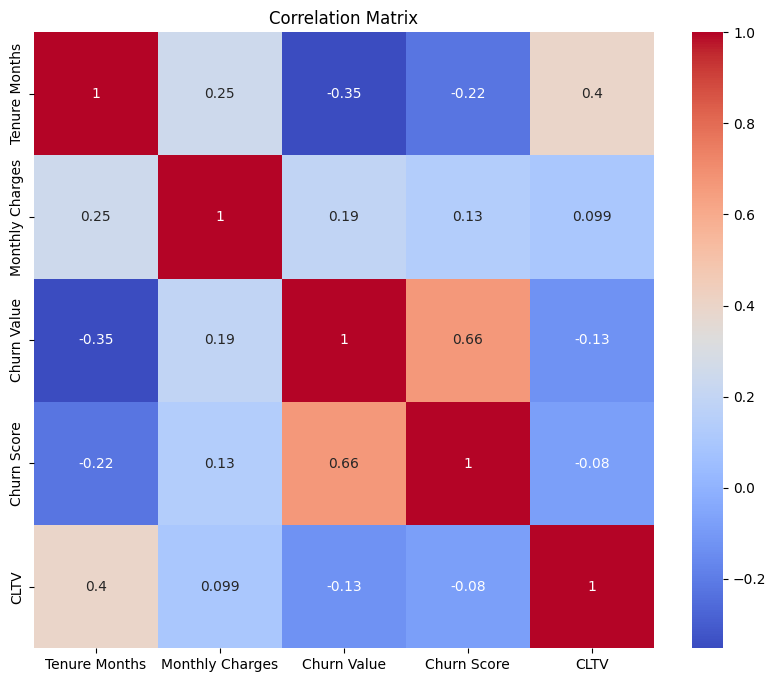

In [190]:
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [191]:
contract_churn = pd.crosstab(df['Contract'], df['Churn Label'], normalize = 'index')
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


Data Cleaning

In [192]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [193]:
df["Total Charges"]

,Total Charges
0,108.15
1,151.65
2,820.5
3,3046.05
4,5036.3
...,...
7038,1419.4
7039,1990.5
7040,7362.9
7041,346.45


In [194]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [195]:
df['Total Charges'].dtype

dtype('float64')

In [196]:
print("Missing Values:", df['Total Charges'].isnull().sum())

Missing Values: 11


In [197]:
df[df['Total Charges'].isnull()]['Tenure Months']

,Tenure Months
2234,0
2438,0
2568,0
2667,0
2856,0
4331,0
4687,0
5104,0
5719,0
6772,0


In [198]:
df[df['Total Charges'].isnull()]['Tenure Months'].shape

(11,)

In [199]:
df['Total Charges'] = df['Total Charges'].fillna(0)

In [200]:
df.shape

(7043, 33)

In [201]:
drop_columns=['CustomerID', 'Count','Country', 'State', 'Zip Code', 'Lat Long','Latitude','Longitude', 'Churn Label', 'Churn Score', 'CLTV', 'Churn Reason']

In [202]:
df = df.drop(columns = drop_columns)
df.head()

,City,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Los Angeles,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Los Angeles,Female,No,No,Yes,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Los Angeles,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
3,Los Angeles,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Los Angeles,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1


In [203]:
df = df.drop(columns=['City'])
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,True,True,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,False


In [204]:
df_encoded.shape

(7043, 31)

In [205]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [206]:
x =  df_encoded.drop('Churn Value',axis = 1)
y = df_encoded['Churn Value']

In [207]:
x.shape

(7043, 30)

In [208]:
y.shape

(7043,)

In [209]:
print(x)

      Tenure Months  Monthly Charges  Total Charges  Gender_Male  \
0                 2            53.85         108.15         True   
1                 2            70.70         151.65        False   
2                 8            99.65         820.50        False   
3                28           104.80        3046.05        False   
4                49           103.70        5036.30         True   
...             ...              ...            ...          ...   
7038             72            21.15        1419.40        False   
7039             24            84.80        1990.50         True   
7040             72           103.20        7362.90        False   
7041             11            29.60         346.45        False   
7042             66           105.65        6844.50         True   

      Senior Citizen_Yes  Partner_Yes  Dependents_Yes  Phone Service_Yes  \
0                  False        False           False               True   
1                  False       

In [210]:
print(y)

0       1
1       1
2       1
3       1
4       1
       ..
7038    0
7039    0
7040    0
7041    0
7042    0
Name: Churn Value, Length: 7043, dtype: int64


ML IMPLEMENTATION

In [211]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [212]:
X_train.shape

(5634, 30)

In [213]:
y_train.shape

(5634,)

In [214]:
X_test.shape

(1409, 30)

In [215]:
y_test.shape

(1409,)

In [216]:
from sklearn.ensemble import RandomForestClassifier

In [217]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [218]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [219]:
y_pred = rf_model.predict(X_test)
y_pred

array([0, 0, 0, ..., 1, 0, 1])

In [220]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [221]:
accuracy=accuracy_score(y_test, y_pred)
accuracy

0.7856635911994322

In [222]:
print(confusion_matrix(y_test, y_pred))

[[902 107]
 [195 205]]


In [223]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1009
           1       0.66      0.51      0.58       400

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



1) Class Imbalance Handling

In [224]:
rf_balanced=RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_balanced.fit(X_train, y_train)
y_pred_balanced=rf_balanced.predict(X_test)
accuracy_balanced=accuracy_score(y_test, y_pred_balanced)
cm_balanced=confusion_matrix(y_test, y_pred_balanced)
cr_balanced=classification_report(y_test, y_pred_balanced)
print("Accuracy:", accuracy_balanced)
print("Confusion Matrix:\n", cm_balanced)
print("Classification Report:\n", cr_balanced)

Accuracy: 0.7920511000709723
Confusion Matrix:
 [[907 102]
 [191 209]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1009
           1       0.67      0.52      0.59       400

    accuracy                           0.79      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



2) Hyperparameter Tuning

In [225]:
rf_tuned=RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight='balanced')
rf_tuned.fit(X_train, y_train)
y_pred_tuned=rf_tuned.predict(X_test)
accuracy_tuned=accuracy_score(y_test, y_pred_tuned)
cm_tuned=confusion_matrix(y_test, y_pred_tuned)
cr_tuned=classification_report(y_test, y_pred_tuned)
print("Accuracy:", accuracy_tuned)
print("Confusion Matrix:\n", cm_tuned)
print("Classification Report:\n", cr_tuned)

Accuracy: 0.7828246983676366
Confusion Matrix:
 [[804 205]
 [101 299]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.59      0.75      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



3) Feature Importance Analysis

In [226]:
feature_importance = pd.DataFrame({'Feature': x.columns, 'Importance': rf_tuned.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print(feature_importance)

                                   Feature  Importance
0                            Tenure Months    0.179069
2                            Total Charges    0.136460
25                       Contract_Two year    0.102861
1                          Monthly Charges    0.093681
6                           Dependents_Yes    0.068517
10            Internet Service_Fiber optic    0.060228
28         Payment Method_Electronic check    0.046732
24                       Contract_One year    0.036682
13                     Online Security_Yes    0.029356
19                        Tech Support_Yes    0.021106
26                   Paperless Billing_Yes    0.018064
5                              Partner_Yes    0.015846
12     Online Security_No internet service    0.014973
18        Tech Support_No internet service    0.014799
22    Streaming Movies_No internet service    0.014360
16   Device Protection_No internet service    0.012985
11                     Internet Service_No    0.012673
3         

In [227]:
X_selected = x.drop(['Phone Service_Yes', 'Multiple Lines_No phone service'], axis = 1)

In [228]:
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(X_selected, y, test_size=0.2, random_state=42)

In [229]:
rf_selected = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight='balanced')
rf_selected.fit(X_train_sel, y_train_sel)
y_pred_selected = rf_selected.predict(X_test_sel)
accuracy_selected = accuracy_score(y_test_sel, y_pred_selected)
print("Accuracy:", accuracy_selected)
print("Confusion Matrix:\n", confusion_matrix(y_test_sel, y_pred_selected))
print(classification_report(y_test_sel, y_pred_selected))

Accuracy: 0.7835344215755855
Confusion Matrix:
 [[807 202]
 [103 297]]
              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.60      0.74      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



In [259]:
import shap

explainer = shap.TreeExplainer(rf_tuned)
explanation = explainer(X_test)

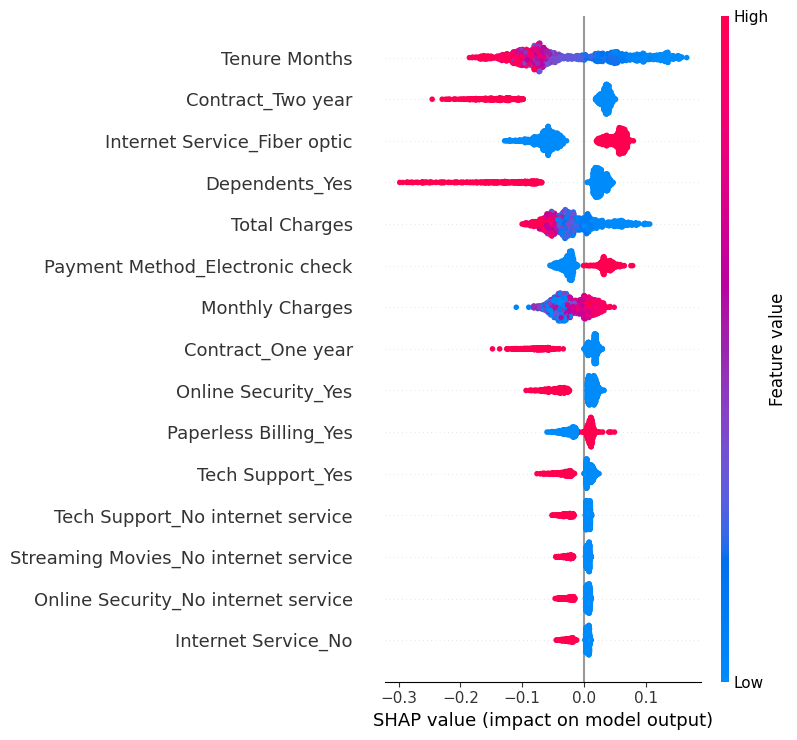

In [260]:
shap.summary_plot(
    explanation.values[:, :, 1],
    X_test,
    feature_names=list(X_test.columns),
    max_display=15
)

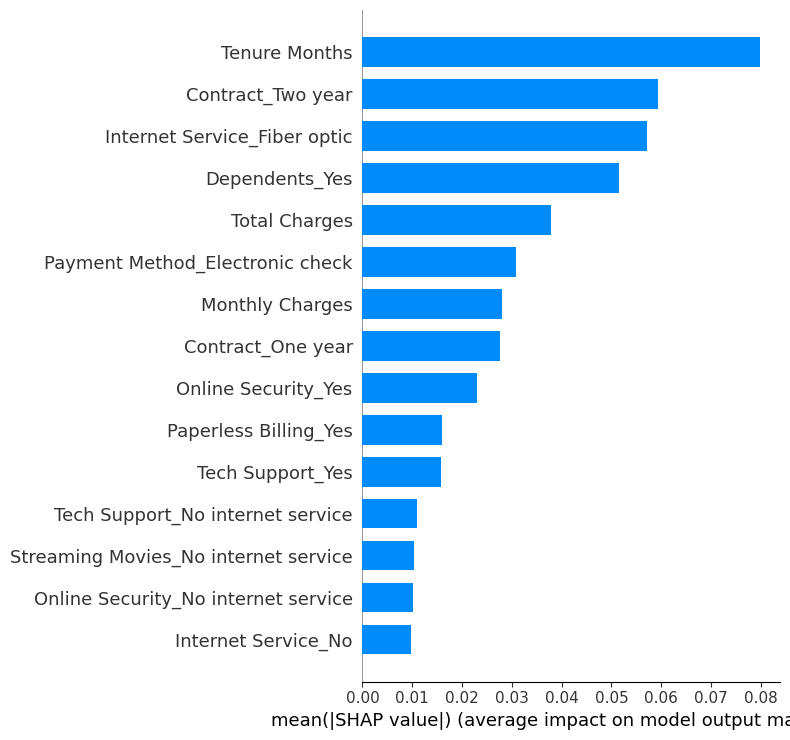

In [261]:
shap.summary_plot(
    explanation.values[:, :, 1],
    X_test,
    feature_names=list(X_test.columns),
    plot_type="bar",
    max_display=15
)

Combination of Trees and Depth

In [231]:
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score

In [262]:
from sklearn.model_selection import (
  GridSearchCV
)

param_grid = {
  'n_estimators': [100, 200, 300],
  'max_depth': [5, 10, 15, 20]
}

grid_search = GridSearchCV(
  RandomForestClassifier(
    class_weight='balanced',
    random_state=42
  ),
  param_grid,
  cv=5,
  scoring='recall',
  n_jobs=-1,
  verbose=1
)
grid_search.fit(X_train, y_train)

print("Best params:",
  grid_search.best_params_)
best_model = grid_search.best_estimator_
y_pred_grid = best_model.predict(X_test)
print("GridSearch Best Model Accuracy:", accuracy_score(y_test, y_pred_grid))
print(classification_report(y_test, y_pred_grid))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'max_depth': 5, 'n_estimators': 200}
GridSearch Best Model Accuracy: 0.7423704755145494
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1009
           1       0.53      0.81      0.64       400

    accuracy                           0.74      1409
   macro avg       0.72      0.76      0.72      1409
weighted avg       0.80      0.74      0.75      1409



In [233]:
from sklearn.model_selection import cross_val_score
final_rf = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42, class_weight='balanced')

In [234]:
cv_accuracy = cross_val_score(final_rf, x, y, cv=5, scoring='accuracy')
cv_accuracy

array([0.78211498, 0.80269695, 0.7707594 , 0.80681818, 0.80042614])

In [235]:
cv_accuracy.mean()

np.float64(0.7925631290728433)

In [236]:
cv_recall = cross_val_score(final_rf, x, y, cv=5, scoring='recall')
cv_recall

array([0.45721925, 0.51871658, 0.5       , 0.51069519, 0.52546917])

In [237]:
cv_recall.mean()

np.float64(0.5024200369887171)

In [238]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

In [239]:
y_prob = rf_tuned.predict_proba(x)

In [240]:
y_prob1 = rf_tuned.predict_proba(X_test)

In [241]:
churn_prob = y_prob[:,1]
churn_prob1 = y_prob1[:,1]
fpr, tpr, threshold = roc_curve(y_test, churn_prob1)
auc_score= roc_auc_score(y_test, churn_prob1)
print("AUC Score:",auc_score)

AUC Score: 0.857104806739346


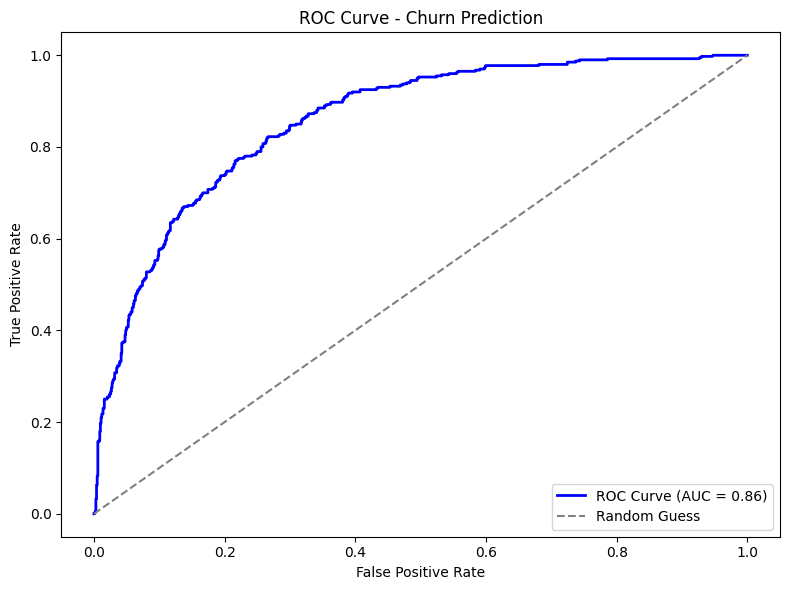

In [256]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', linewidth=2, label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5, label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Churn Prediction')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Customer Segmentation

In [242]:
segmentation_data = pd.DataFrame({
    'Tenure Months': x['Tenure Months'].values,
    'Monthly Charges': x['Monthly Charges'].values,
    'Total Charges': df['Total Charges'].values,
    'Churn Probability': churn_prob})

In [243]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
0,2,53.85,108.15,0.676963
1,2,70.70,151.65,0.796013
2,8,99.65,820.50,0.805827
3,28,104.80,3046.05,0.563031
4,49,103.70,5036.30,0.517474
...,...,...,...,...
7038,72,21.15,1419.40,0.003587
7039,24,84.80,1990.50,0.082095
7040,72,103.20,7362.90,0.049001
7041,11,29.60,346.45,0.302367


In [244]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(segmentation_data)
print(scaled_data[:5])

[[-1.23672422 -0.36266036 -0.9580659   1.02486837]
 [-1.23672422  0.19736523 -0.93887444  1.4138535 ]
 [-0.99240204  1.1595457  -0.64378925  1.44591771]
 [-0.17799476  1.33071079  0.3380854   0.65260685]
 [ 0.67713287  1.29415125  1.2161497   0.50375182]]


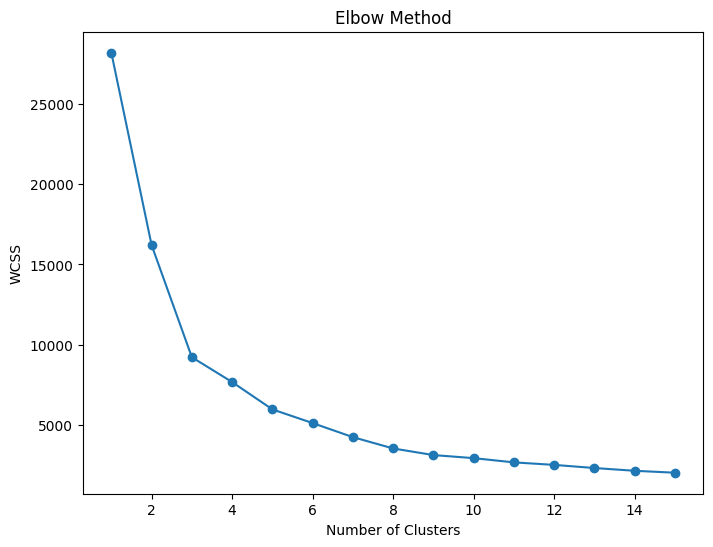

In [257]:
from sklearn.cluster import KMeans
wcss=[]
for k in range(1,16):
  kmeans = KMeans(n_clusters = k, random_state = 42)
  kmeans.fit(scaled_data)
  wcss.append(kmeans.inertia_)
plt.figure(figsize=(8,6))
plt.plot(range(1,16), wcss, marker ='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

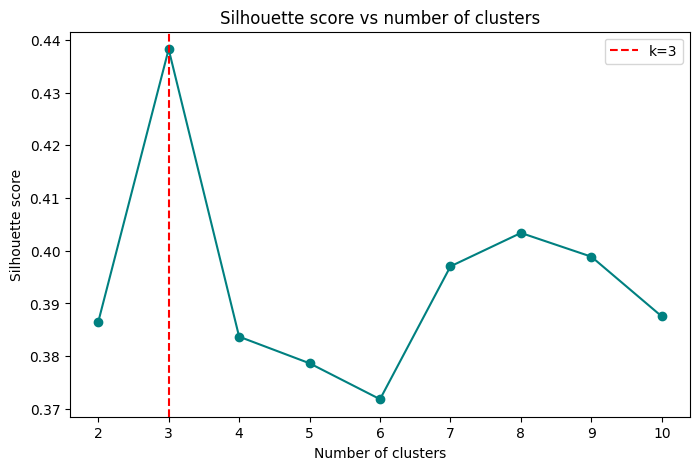

Best k by silhouette: 3


In [258]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), silhouette_scores,
         marker='o', color='teal')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.title('Silhouette score vs number of clusters')
plt.axvline(x=3, color='red',
            linestyle='--', label='k=3')
plt.legend()
plt.show()

best_k = list(k_range)[
    silhouette_scores.index(max(silhouette_scores))
]
print(f"Best k by silhouette: {best_k}")

In [246]:
kmeans = KMeans(n_clusters = 3, random_state = 42)
clusters = kmeans.fit_predict(scaled_data)

In [247]:
segmentation_data['Cluster'] = clusters
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster
0,2,53.85,108.15,0.676963,1
1,2,70.70,151.65,0.796013,1
2,8,99.65,820.50,0.805827,1
3,28,104.80,3046.05,0.563031,1
4,49,103.70,5036.30,0.517474,2
...,...,...,...,...,...
7038,72,21.15,1419.40,0.003587,0
7039,24,84.80,1990.50,0.082095,0
7040,72,103.20,7362.90,0.049001,2
7041,11,29.60,346.45,0.302367,0


In [248]:
cluster_summary = segmentation_data.groupby('Cluster').mean()
cluster_summary

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
Cluster,,,,
0,32.051471,32.845761,1047.702141,0.120599
1,10.957752,71.961298,884.069671,0.691383
2,58.398884,90.430986,5278.001674,0.230647


In [249]:
cluster_names = {
    0: 'Budget Loyal Customers',
    1: ' High Risk New Customers',
    2: 'Loyal Premium Customers'
}

In [250]:
segmentation_data['Cluster Segmentation'] =  segmentation_data['Cluster'].map(cluster_names)
segmentation_data.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster,Cluster Segmentation
0,2,53.85,108.15,0.676963,1,High Risk New Customers
1,2,70.70,151.65,0.796013,1,High Risk New Customers
2,8,99.65,820.50,0.805827,1,High Risk New Customers
3,28,104.80,3046.05,0.563031,1,High Risk New Customers
4,49,103.70,5036.30,0.517474,2,Loyal Premium Customers


In [268]:
print("Cluster Sizes:")
print(segmentation_data['Cluster Segmentation'].value_counts())
print("\nAverage Churn Probability per Segment:")
print(segmentation_data.groupby('Cluster Segmentation')['Churn Probability'].mean())

Cluster Sizes:
Cluster Segmentation
 High Risk New Customers    2580
Budget Loyal Customers      2312
Loyal Premium Customers     2151
Name: count, dtype: int64

Average Churn Probability per Segment:
Cluster Segmentation
 High Risk New Customers    0.691383
Budget Loyal Customers      0.120599
Loyal Premium Customers     0.230647
Name: Churn Probability, dtype: float64


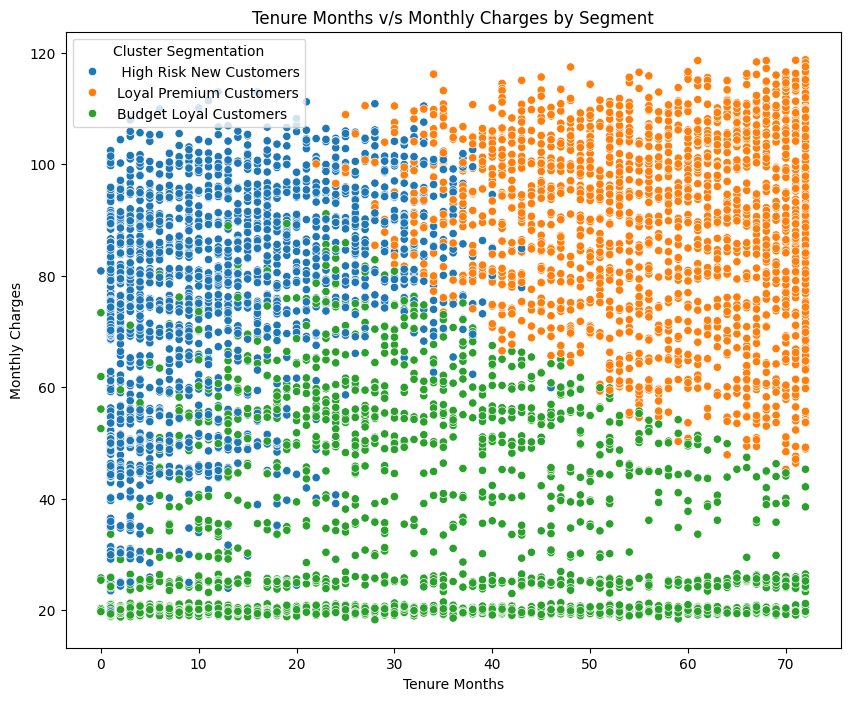

In [265]:
plt.figure(figsize=(10,8))
sns.scatterplot(x='Tenure Months', y='Monthly Charges', hue='Cluster Segmentation', data=segmentation_data)
plt.xlabel('Tenure Months')
plt.ylabel('Monthly Charges')
plt.title('Tenure Months v/s Monthly Charges by Segment')
plt.show()

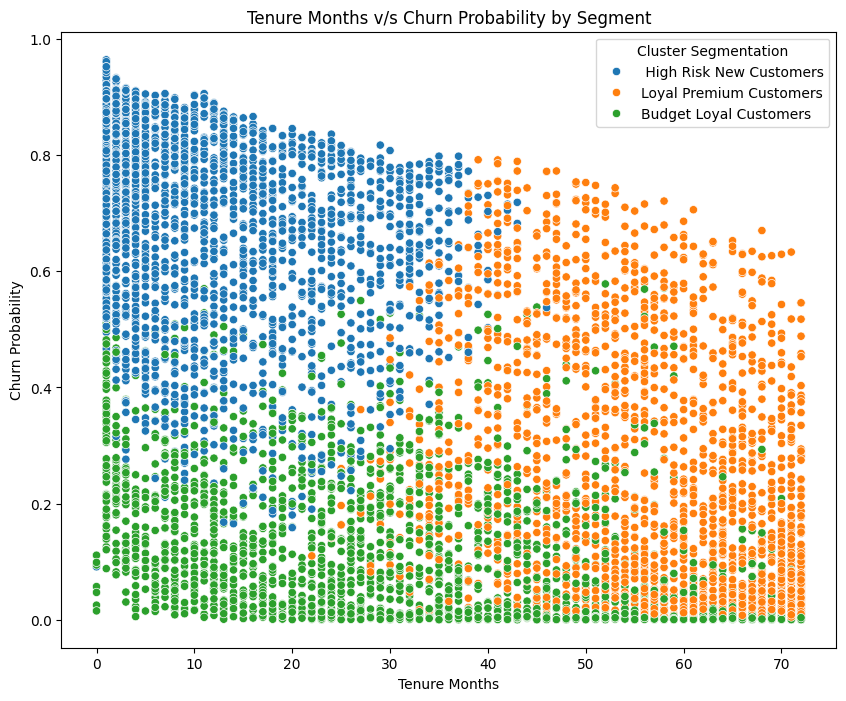

In [264]:
plt.figure(figsize=(10,8))
sns.scatterplot(x='Tenure Months', y='Churn Probability', hue='Cluster Segmentation', data=segmentation_data)
plt.xlabel('Tenure Months')
plt.ylabel('Churn Probability')
plt.title('Tenure Months v/s Churn Probability by Segment')
plt.show()

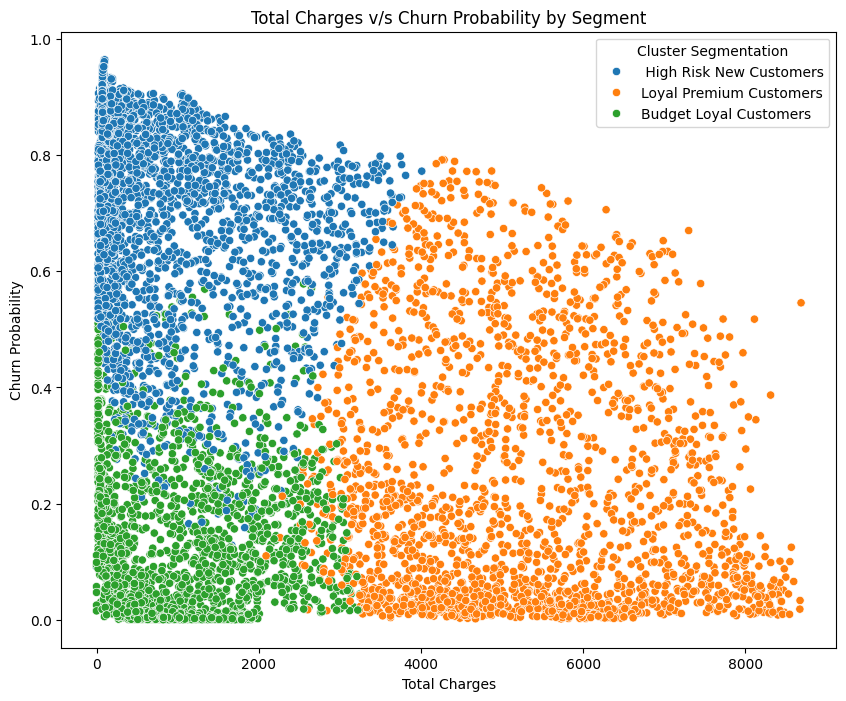

In [263]:
plt.figure(figsize=(10,8))
sns.scatterplot(x='Total Charges', y='Churn Probability', hue='Cluster Segmentation', data=segmentation_data)
plt.xlabel('Total Charges')
plt.ylabel('Churn Probability')
plt.title('Total Charges v/s Churn Probability by Segment')
plt.show()